# mcl-PHAs / DTS data / Storage modulus - Preprocessing

**Author:** Lab of Farm Structures
**Date:** 2026-05

## Import libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import math
import re

## Import Data

In [44]:
database = 'Rheological Properties Data Libraries of mcl-PHAs_V03_corrected'

## Create DataFrames for data points and properties

In [45]:
# Physicochemical properties DataFrame
df_physicochem = pd.read_excel(f'{database}.xlsx', sheet_name='Physchem_properties')

# Complex viscosity properties DataFrame
df_storage = pd.read_excel(f'{database}.xlsx', sheet_name='converted_MPa_Storage_modulus_G')

# Temperature DataFrame
df_temp = pd.read_excel(f'{database}.xlsx', sheet_name='Temperature(°C)')

# Experimental details DataFrame
df_exp = pd.read_excel(f'{database}.xlsx', sheet_name='Rheological_experimental_detail')

## Drop duplicates and remove multiple study+instance case (keep first)

In [46]:
print("Physicochemical Properties, rows before:", df_physicochem.shape[0])
df_physicochem = df_physicochem.drop_duplicates(subset=['Study_id', 'Instance'])
print("Physicochemical Properties, rows after:", df_physicochem.shape[0])

Physicochemical Properties, rows before: 26
Physicochemical Properties, rows after: 22


## Keep DTS data

In [47]:
exp_dict_dfs = (
    df_exp[df_exp['Test type'] == 'DTS']
    .groupby('Study_id')['Instance']
    .apply(list)
    .to_dict()
)

In [48]:
# Flatten exp_dict_dfs into a DataFrame of valid (Study_id, Instance) pairs
exp_pairs = [(sid, inst) for sid, instances in exp_dict_dfs.items() for inst in instances]
df_exp_pairs = pd.DataFrame(exp_pairs, columns=['Study_id', 'Instance'])

# Filter df_storage
df_storage_filtered = df_storage.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Filter df_temp
df_temp_filtered = df_temp.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Filter df_exp
df_exp_filtered = df_exp.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# FIlter df_physicochem
df_physic_filtered = df_physicochem.merge(df_exp_pairs, on=['Study_id', 'Instance'], how='inner')

# Check all dfs have the same rows
df_storage_filtered.shape, df_temp_filtered.shape, df_exp_filtered.shape, df_physic_filtered.shape

((24, 23), (24, 23), (24, 18), (16, 33))

## Merge properties

In [49]:
df_merged_prop = pd.merge(df_physic_filtered, df_exp_filtered,  on=['Study_id', 'Instance'], how='left')
df_merged_prop.tail()

,Study_id,Instance,scl PHA ratio (mol%),3HB ratio (mol%),3HV ratio (mol%),mcl PHA ratio (mol%),3HHx ratio (mol%),3HHp ratio (mol%),3HO ratio (mol%),3HN ratio (mol%),...,diameter,thickness,size units,Angular_frequency_units,Texp,Texp_units,Viscosity_units,Modulus_units,Strain_fixed(%),Frequency_experimental_fixed (Hz)
35,9,5,0,0.0,0.0,100,NaN,0,86.0,0,...,NaN,NaN,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0
36,9,6,0,0.0,0.0,100,NaN,0,86.0,0,...,NaN,NaN,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0
37,9,7,0,0.0,0.0,100,NaN,0,86.0,0,...,NaN,NaN,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0
38,10,1,0,0.0,0.0,104,5.0,0,20.0,0,...,NaN,NaN,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6
39,11,1,1,1.0,0.0,99,2.0,0,25.0,0,...,NaN,NaN,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6


## Melt temperature values

In [50]:
id_cols = ["Study_id", "Instance"]

value_cols = [c for c in df_temp_filtered.columns if c not in id_cols]

df_temp_filtered[value_cols] = df_temp_filtered[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
f_long = (
    df_temp_filtered
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(name="f_value")
    .dropna(subset=["f_value"])
)
f_long.head()

,Study_id,Instance,level_2,f_value
0,3.0,1.0,Unnamed: 2,-123.0
1,3.0,1.0,Unnamed: 3,-115.0
2,3.0,1.0,Unnamed: 4,-105.0
3,3.0,1.0,Unnamed: 5,-95.0
4,3.0,1.0,Unnamed: 6,-85.0


## Melt storage modulus values

In [51]:
id_cols = ["Study_id", "Instance"]

value_cols = [c for c in df_storage_filtered.columns if c not in id_cols]

df_storage_filtered[value_cols] = df_storage_filtered[value_cols].apply(
    pd.to_numeric, errors="coerce"
)
v_long = (
    df_storage_filtered
    .set_index(id_cols)[value_cols]
    .stack()
    .reset_index(name="v_value")
    .dropna(subset=["v_value"])
)
v_long.head()

,Study_id,Instance,level_2,v_value
0,3,1,Unnamed: 2,1909.853259
1,3,1,Unnamed: 3,1782.378767
2,3,1,Unnamed: 4,1737.800829
3,3,1,Unnamed: 5,1621.810097
4,3,1,Unnamed: 6,1513.561248


## Merge f and v values

In [52]:
fv_df = (
    f_long.merge(
        v_long,
        on=["Study_id", "Instance", "level_2"],
        how="inner",
#        validate="one_to_one"
    )
)
fv_df.head()

,Study_id,Instance,level_2,f_value,v_value
0,3.0,1.0,Unnamed: 2,-123.0,1909.853259
1,3.0,1.0,Unnamed: 2,-123.0,1909.853259
2,3.0,1.0,Unnamed: 2,-123.0,1435.489433
3,3.0,1.0,Unnamed: 2,-123.0,1435.489433
4,3.0,1.0,Unnamed: 3,-115.0,1782.378767


In [53]:
# check size
f_long.shape, v_long.shape, fv_df.shape

((412, 4), (397, 4), (1259, 5))

## Merge properties with f,v values

In [54]:
df_merged_fnl = df_merged_prop.merge(
    fv_df[['Study_id', 'Instance', 'f_value', 'v_value']],
    on=['Study_id', 'Instance'],
    how='left'
)
df_merged_fnl = df_merged_fnl.dropna(subset=['f_value', 'v_value'])
df_merged_fnl.tail()

,Study_id,Instance,scl PHA ratio (mol%),3HB ratio (mol%),3HV ratio (mol%),mcl PHA ratio (mol%),3HHx ratio (mol%),3HHp ratio (mol%),3HO ratio (mol%),3HN ratio (mol%),...,size units,Angular_frequency_units,Texp,Texp_units,Viscosity_units,Modulus_units,Strain_fixed(%),Frequency_experimental_fixed (Hz),f_value,v_value
9403,11,1,1,1.0,0.0,99,2.0,0,25.0,0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,25.0,1314.398518
9404,11,1,1,1.0,0.0,99,2.0,0,25.0,0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,35.0,588.694076
9405,11,1,1,1.0,0.0,99,2.0,0,25.0,0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,45.0,118.090613
9406,11,1,1,1.0,0.0,99,2.0,0,25.0,0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,55.0,24.921423
9407,11,1,1,1.0,0.0,99,2.0,0,25.0,0,...,NaN,NaN,NaN,celsius,NaN,NaN,NaN,1.6,65.0,16.192062


In [55]:
df_merged_fnl.shape

(9407, 51)

## Rename columns

In [56]:
df_merged_fnl = df_merged_fnl.rename(columns={
    'f_value': 'temperature',
    'v_value': 'storage_modulus'
})

df_merged_fnl.columns

Index(['Study_id', 'Instance', 'scl PHA ratio (mol%)', '3HB ratio (mol%)',
       '3HV ratio (mol%)', 'mcl PHA ratio (mol%)', '3HHx ratio (mol%)',
       '3HHp ratio (mol%)', '3HO ratio (mol%)', '3HN ratio (mol%)',
       '3HD ratio (mol%)', '3HUD ratio (mol%)', '3HDD ratio (mol%)',
       '3HTriD ratio (mol%)', '3HTTD ratio (mol%)',
       'Unsaturated monomer ratio (mol%)', 'Uknown monomer ratio (mol%)', 'Mw',
       'Mn', 'Density', 'Density_units', 'PDI', 'Additive', 'Additive1_type',
       'Additive1_name', 'Additive1_percentage (wt%)', 'Additive_2',
       'Additive2_type', 'Additive2_name', 'Additive2_percentage (wt%)',
       'final_PHA_percentage (wt%)', 'Unnamed: 31', 'Row No', 'Test type',
       'constant parameters', 'geometry', 'plate diameter', 'gap size',
       'morphology', 'diameter', 'thickness', 'size units',
       'Angular_frequency_units', 'Texp', 'Texp_units', 'Viscosity_units',
       'Modulus_units', 'Strain_fixed(%)', 'Frequency_experimental_fixed (Hz)',
  

## Drop duplicates

In [57]:
df_merged_fnl = df_merged_fnl.drop_duplicates()

## Replace N/A values with nan

In [58]:
df_merged_fnl = df_merged_fnl.replace(
    ["N/A", "n/a", "NA", "na"],
    np.nan
)

C:\Users\leoni\AppData\Local\Temp\ipykernel_22560\3689305899.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_merged_fnl = df_merged_fnl.replace(


## Fill in Mw, given PDI = Mw / Mn

In [59]:
mask_Mw = (
    df_merged_fnl['Mw'].isna() &
    df_merged_fnl['Mn'].notna() &
    df_merged_fnl['PDI'].notna()
)

df_merged_fnl.loc[mask_Mw, 'Mw'] = (
    df_merged_fnl.loc[mask_Mw, 'PDI'] * df_merged_fnl.loc[mask_Mw, 'Mn']
)

## Fix typos, excl. special characters

In [60]:
def clean_column_name(col):
    col = col.strip().lower()
    col = re.sub(r'[%()]', '', col)        # remove % ( )
    col = re.sub(r'[\/]', '_', col)        # / → _
    col = re.sub(r'\s+', '_', col)         # spaces → _
    col = re.sub(r'[^a-z0-9_]', '', col)   # remove remaining special chars
    col = re.sub(r'_+', '_', col)           # collapse multiple _
    col = col.strip('_')
    return col

def clean_cell_value(val):
    if isinstance(val, str):
        val = val.strip().lower()
        val = re.sub(r'[%()]', '', val)       # remove % ( )
        val = re.sub(r'[\/]', '_', val)       # / → _
        val = re.sub(r'\s+', '_', val)        # spaces → _
        val = re.sub(r'[^a-z0-9_]', '', val)  # remove remaining special chars
        val = re.sub(r'_+', '_', val)         # collapse multiple _
        val = val.strip('_')
    return val


In [61]:
df_merged_fnl.columns = [clean_column_name(c) for c in df_merged_fnl.columns]
df_merged_fnl.head()

,study_id,instance,scl_pha_ratio_mol,3hb_ratio_mol,3hv_ratio_mol,mcl_pha_ratio_mol,3hhx_ratio_mol,3hhp_ratio_mol,3ho_ratio_mol,3hn_ratio_mol,...,size_units,angular_frequency_units,texp,texp_units,viscosity_units,modulus_units,strain_fixed,frequency_experimental_fixed_hz,temperature,storage_modulus
0,3,1,0,0.0,0.0,100,NaN,0,86.0,0,...,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0,-123.0,1909.853259
2,3,1,0,0.0,0.0,100,NaN,0,86.0,0,...,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0,-123.0,1435.489433
4,3,1,0,0.0,0.0,100,NaN,0,86.0,0,...,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0,-115.0,1782.378767
6,3,1,0,0.0,0.0,100,NaN,0,86.0,0,...,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0,-115.0,1402.813705
8,3,1,0,0.0,0.0,100,NaN,0,86.0,0,...,NaN,Hz,NaN,celsius,NaN,Pa,NaN,1.0,-105.0,1737.800829


In [62]:
df_clean = df_merged_fnl.copy()

# apply only to object (string) columns
obj_cols = df_clean.select_dtypes(include='object').columns

df_clean[obj_cols] = df_clean[obj_cols].apply( lambda col: col.map(clean_cell_value) )

In [63]:
df_clean.columns

Index(['study_id', 'instance', 'scl_pha_ratio_mol', '3hb_ratio_mol',
       '3hv_ratio_mol', 'mcl_pha_ratio_mol', '3hhx_ratio_mol',
       '3hhp_ratio_mol', '3ho_ratio_mol', '3hn_ratio_mol', '3hd_ratio_mol',
       '3hud_ratio_mol', '3hdd_ratio_mol', '3htrid_ratio_mol',
       '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol', 'mw', 'mn', 'density', 'density_units',
       'pdi', 'additive', 'additive1_type', 'additive1_name',
       'additive1_percentage_wt', 'additive_2', 'additive2_type',
       'additive2_name', 'additive2_percentage_wt', 'final_pha_percentage_wt',
       'unnamed_31', 'row_no', 'test_type', 'constant_parameters', 'geometry',
       'plate_diameter', 'gap_size', 'morphology', 'diameter', 'thickness',
       'size_units', 'angular_frequency_units', 'texp', 'texp_units',
       'viscosity_units', 'modulus_units', 'strain_fixed',
       'frequency_experimental_fixed_hz', 'temperature', 'storage_modulus'],
      dtype='object')

In [64]:
df_clean.loc[df_clean['additive1_percentage_wt'].isna(), 'additive1_percentage_wt'] = 0
df_clean.loc[df_clean['additive2_percentage_wt'].isna(), 'additive2_percentage_wt'] = 0

df_clean['additive_1'] = df_clean['additive1_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')
df_clean['additive_2'] = df_clean['additive2_percentage_wt'].apply(lambda x: 'yes' if x > 0 else 'no')

df_clean.loc[df_clean['additive_1'] == 'no', 'additive1_type'] = 'no_additive'
df_clean.loc[df_clean['additive_2'] == 'no', 'additive2_type'] = 'no_additive'

C:\Users\leoni\AppData\Local\Temp\ipykernel_22560\2238488554.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'no_additive' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_clean.loc[df_clean['additive_2'] == 'no', 'additive2_type'] = 'no_additive'


## Drop features with more than 50% missing values

In [65]:
df_clean = df_clean.loc[:, df_clean.isna().mean() < 0.50]
df_clean.columns

Index(['study_id', 'instance', 'scl_pha_ratio_mol', '3hb_ratio_mol',
       '3hv_ratio_mol', 'mcl_pha_ratio_mol', '3hhp_ratio_mol', '3ho_ratio_mol',
       '3hn_ratio_mol', '3hud_ratio_mol', '3hdd_ratio_mol', '3htrid_ratio_mol',
       '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol', 'additive', 'additive1_type',
       'additive1_name', 'additive1_percentage_wt', 'additive_2',
       'additive2_type', 'additive2_percentage_wt', 'final_pha_percentage_wt',
       'row_no', 'test_type', 'constant_parameters', 'angular_frequency_units',
       'texp_units', 'modulus_units', 'frequency_experimental_fixed_hz',
       'temperature', 'storage_modulus', 'additive_1'],
      dtype='object')

## Feature engineering

In [66]:
df_clean['additive1_type'].value_counts()

additive1_type
reinforcment_and_stiffening_modifiers    149
no_additive                               97
Name: count, dtype: int64

In [67]:
df_clean['additive2_type'].value_counts()

additive2_type
no_additive    246
Name: count, dtype: int64

## Feature selection

In [68]:
# Numerical columns
numerical_cols_lst = [
 'scl_pha_ratio_mol', '3hb_ratio_mol',
       '3hv_ratio_mol', 'mcl_pha_ratio_mol', '3hhp_ratio_mol', '3ho_ratio_mol',
       '3hn_ratio_mol', '3hud_ratio_mol', '3hdd_ratio_mol', '3htrid_ratio_mol',
       '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol',  'additive1_percentage_wt', 'additive2_percentage_wt', 'final_pha_percentage_wt',
        'frequency_experimental_fixed_hz',
       'temperature', 'storage_modulus'
]
# Categorical columns
categorical_cols_lst = [
    'additive1_type',
    'additive'
]

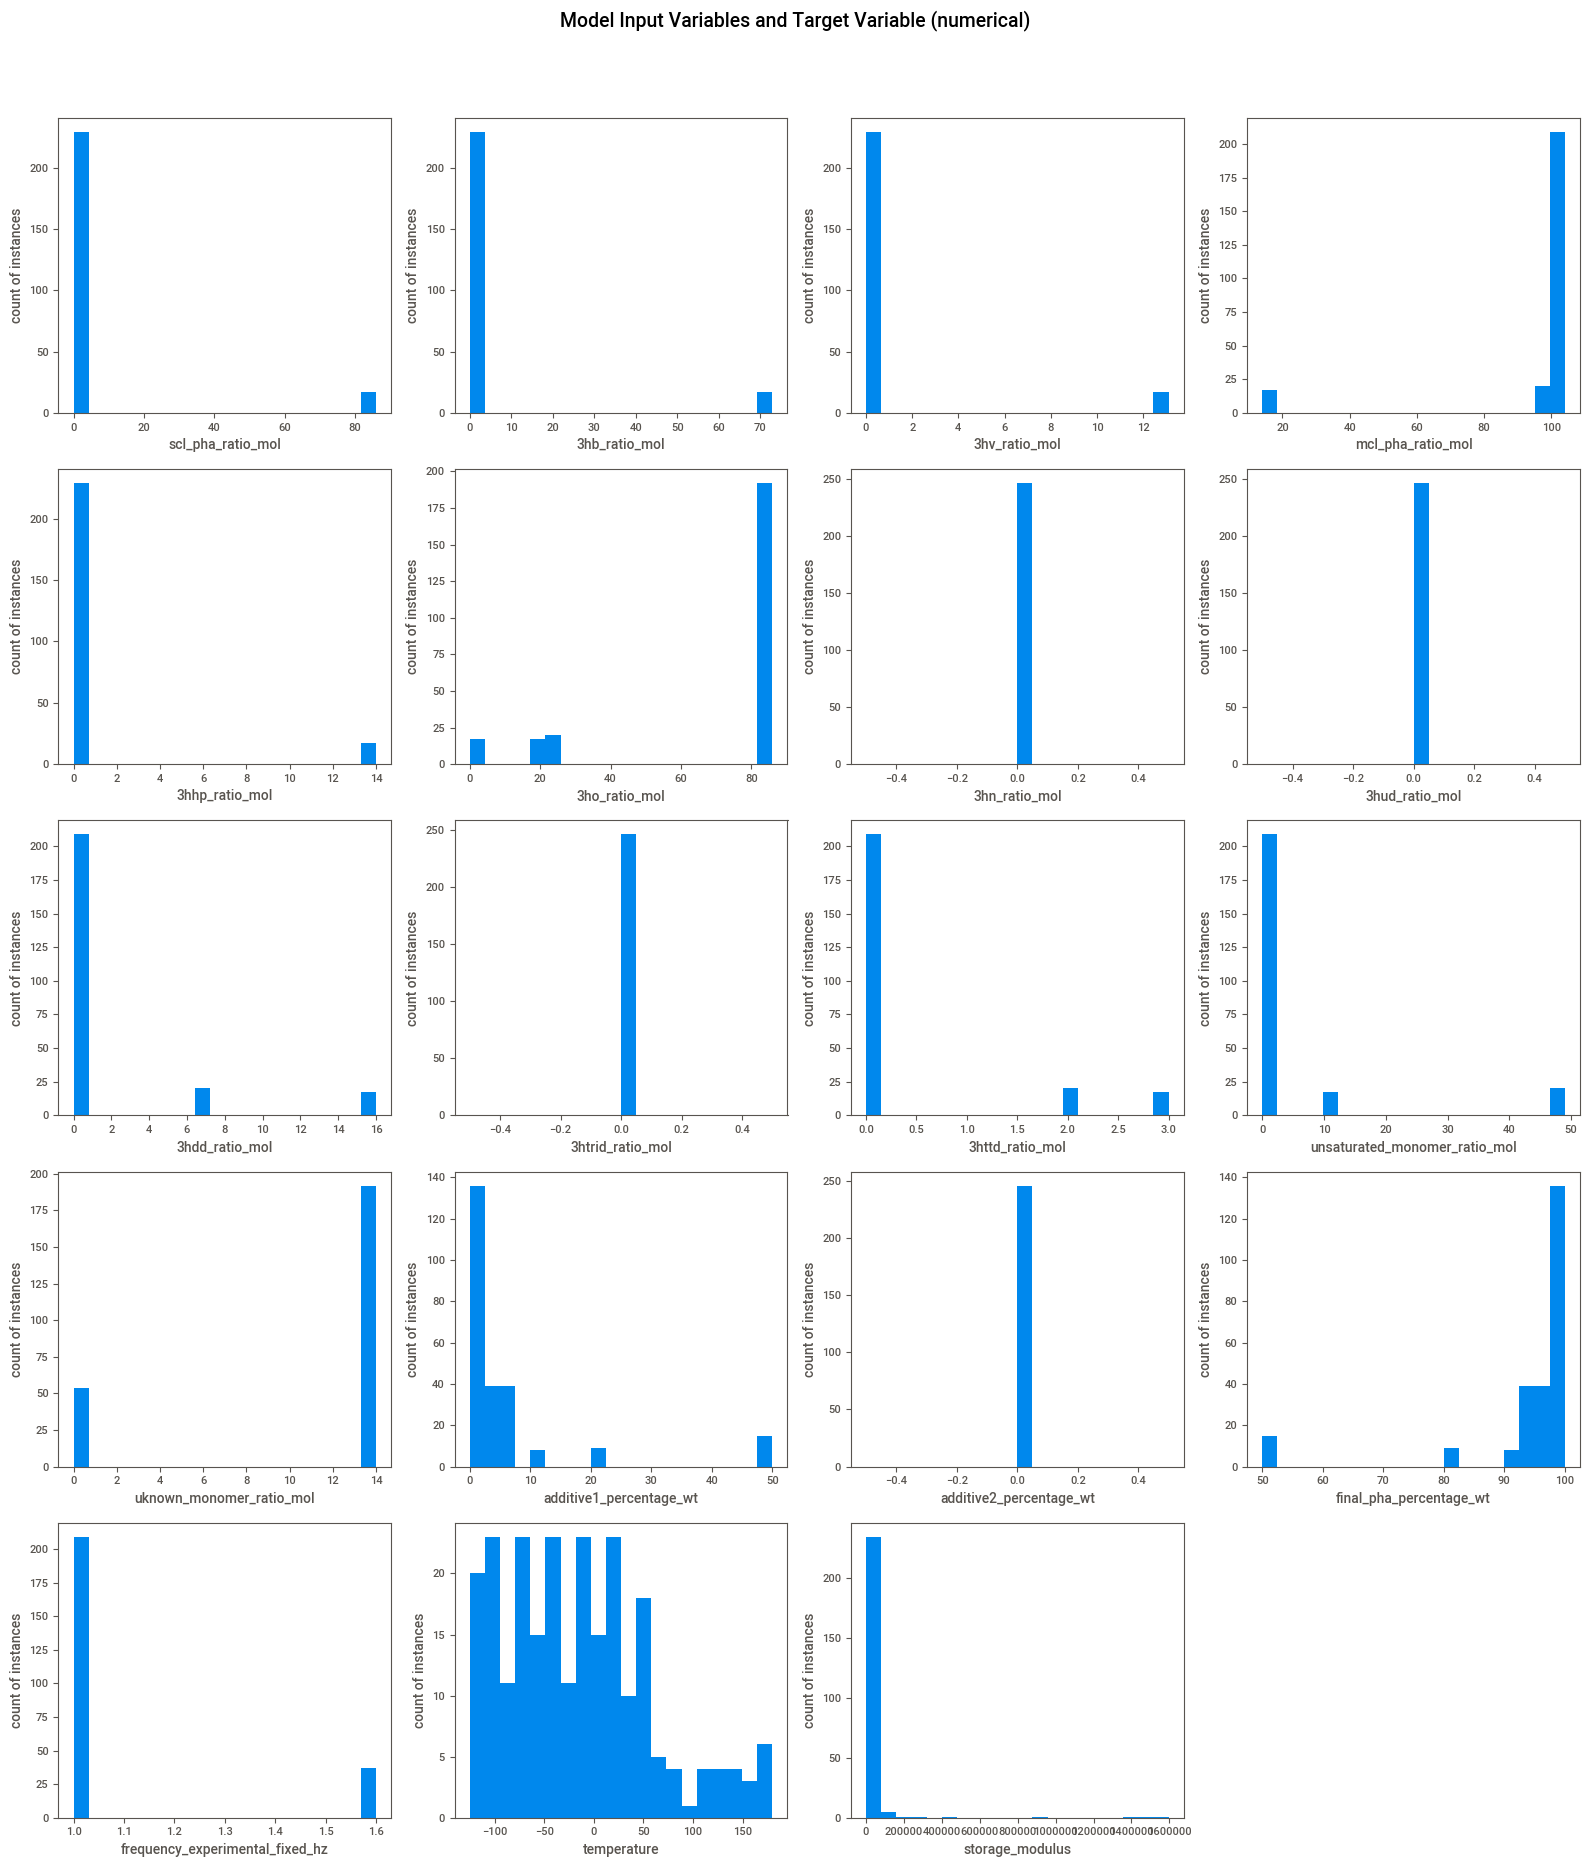

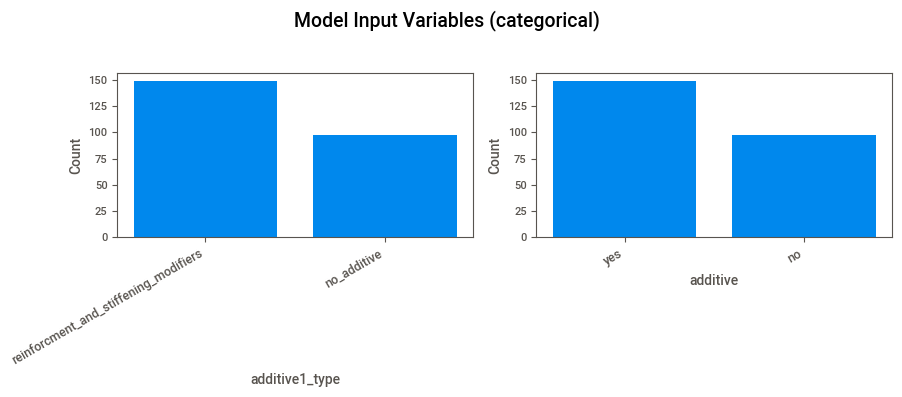

In [69]:
def plot_feature_distributions(
    df: pd.DataFrame,
    numerical_cols,
    categorical_cols,
    title_numeric="Model Input Variables and Target Variable (numerical)",
    title_categorical="Model Input Variables (categorical)",
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,   # cap bars for very high-cardinality cats
):
    # ---------- helper to grid-plot ----------
    def _grid_dims(n, max_cols):
        cols = min(max_cols, max(1, n))
        rows = int(math.ceil(n / cols))
        return rows, cols

    # ---------- NUMERICAL ----------
    if len(numerical_cols) > 0:
        n = len(numerical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.0*cols, 3.8*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_numeric, fontsize=14, y=0.98)

        for i, col in enumerate(numerical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            x = df[col].dropna().values
            ax.hist(x, bins=bins)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("count of instances")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    # ---------- CATEGORICAL ----------
    if len(categorical_cols) > 0:
        n = len(categorical_cols)
        rows, cols = _grid_dims(n, max_cols_per_row)
        fig, axes = plt.subplots(rows, cols, figsize=(4.6*cols, 4.0*rows))
        axes = np.atleast_2d(axes)
        fig.suptitle(title_categorical, fontsize=14, y=0.98)

        for i, col in enumerate(categorical_cols):
            r, c = divmod(i, cols)
            ax = axes[r, c]
            vc = (df[col].astype(str).replace("nan", np.nan)
                                 .value_counts(dropna=False)
                                 .head(top_k_categories))
            ax.bar(range(len(vc)), vc.values)
            ax.set_xticks(range(len(vc)))
            ax.set_xticklabels(vc.index.astype(str), rotation=30, ha="right", fontsize=9)
            #ax.set_title(str(col), fontsize=10)
            ax.set_ylabel("Count")
            ax.set_xlabel(str(col))
            ax.grid(False)

        # hide any empty axes
        for j in range(n, rows*cols):
            r, c = divmod(j, cols)
            axes[r, c].axis("off")

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

plot_feature_distributions(
    df_clean,
    numerical_cols_lst,
    categorical_cols_lst,
    bins=20,
    max_cols_per_row=4,
    top_k_categories=20,
)

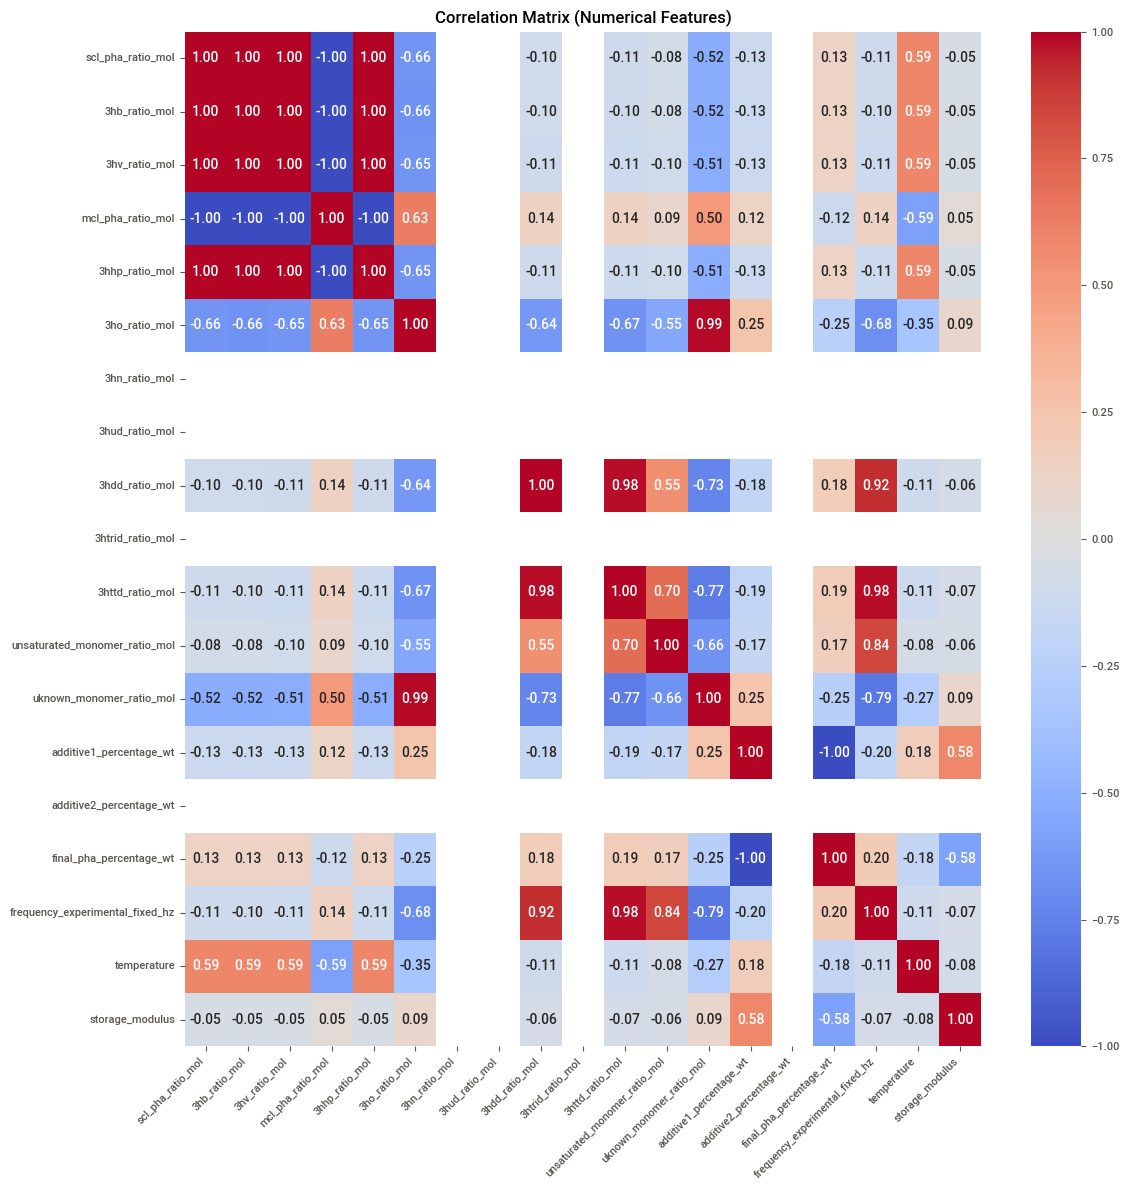

In [70]:
numerical_df = df_clean[numerical_cols_lst].copy()

# Compute correlation matrix
corr_matrix = numerical_df.corr() 

plt.figure(figsize=(12, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (Numerical Features)")
plt.xticks(rotation=45, ha="right") 
plt.yticks(rotation=0) 

plt.tight_layout()
# plt.savefig("correlation.tiff", format="tiff", dpi=600, bbox_inches="tight")
plt.show()

In [71]:
# Select Features and Target
features = [
            'study_id', 'instance',  '3hb_ratio_mol', '3ho_ratio_mol',
       '3hdd_ratio_mol', 
       '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol',  'additive1_percentage_wt', 'additive1_type', 'final_pha_percentage_wt',
        'frequency_experimental_fixed_hz',
       'temperature'
           ]

target = 'storage_modulus'
measure_unit = 'MPa'

In [72]:
# Create cleaned DataFrame
df_new = df_clean[features + [target]]

df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 0 to 9407
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   study_id                         246 non-null    int64  
 1   instance                         246 non-null    int64  
 2   3hb_ratio_mol                    246 non-null    float64
 3   3ho_ratio_mol                    246 non-null    float64
 4   3hdd_ratio_mol                   246 non-null    int64  
 5   3httd_ratio_mol                  246 non-null    int64  
 6   unsaturated_monomer_ratio_mol    246 non-null    int64  
 7   uknown_monomer_ratio_mol         246 non-null    int64  
 8   additive1_percentage_wt          246 non-null    float64
 9   additive1_type                   246 non-null    object 
 10  final_pha_percentage_wt          246 non-null    float64
 11  frequency_experimental_fixed_hz  246 non-null    float64
 12  temperature               

## Drop rows with nan value

In [73]:
mask = (
    df_new[target].notna() &
    df_new[features].notna().all(axis=1)
)

# Create final dataset
df_final = df_new.loc[mask, features + [target]]
df_final.columns = df_final.columns.str.replace(' ', '_', regex=False)

# Check the DataFrame
df_final.head()

,study_id,instance,3hb_ratio_mol,3ho_ratio_mol,3hdd_ratio_mol,3httd_ratio_mol,unsaturated_monomer_ratio_mol,uknown_monomer_ratio_mol,additive1_percentage_wt,additive1_type,final_pha_percentage_wt,frequency_experimental_fixed_hz,temperature,storage_modulus
0,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-123.0,1909.853259
2,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-123.0,1435.489433
4,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-115.0,1782.378767
6,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-115.0,1402.813705
8,3,1,0.0,86.0,0,0,0,14,0.0,no_additive,100.0,1.0,-105.0,1737.800829


In [74]:
df_final['temperature'].describe()

count    246.000000
mean     -16.113821
std       72.609012
min     -125.000000
25%      -75.000000
50%      -25.000000
75%       25.000000
max      180.000000
Name: temperature, dtype: float64

In [75]:
df_final['storage_modulus'].describe()

count    2.460000e+02
mean     3.054841e+04
std      1.774001e+05
min      1.140250e-01
25%      1.237513e+02
50%      1.123347e+03
75%      2.294828e+03
max      1.595879e+06
Name: storage_modulus, dtype: float64

In [76]:
df_final = df_final.copy()
df_final['log_storage_modulus'] = np.log10(df_final['storage_modulus'])

In [77]:
df_final.columns

Index(['study_id', 'instance', '3hb_ratio_mol', '3ho_ratio_mol',
       '3hdd_ratio_mol', '3httd_ratio_mol', 'unsaturated_monomer_ratio_mol',
       'uknown_monomer_ratio_mol', 'additive1_percentage_wt', 'additive1_type',
       'final_pha_percentage_wt', 'frequency_experimental_fixed_hz',
       'temperature', 'storage_modulus', 'log_storage_modulus'],
      dtype='object')

## Remove features with only one value

In [78]:
constant_cols = df_final.columns[df_final.nunique(dropna=True) <= 1]
print("Removed columns:", list(constant_cols))
df_final = df_final.drop(columns=constant_cols)

Removed columns: []


In [79]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 246 entries, 0 to 9407
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   study_id                         246 non-null    int64  
 1   instance                         246 non-null    int64  
 2   3hb_ratio_mol                    246 non-null    float64
 3   3ho_ratio_mol                    246 non-null    float64
 4   3hdd_ratio_mol                   246 non-null    int64  
 5   3httd_ratio_mol                  246 non-null    int64  
 6   unsaturated_monomer_ratio_mol    246 non-null    int64  
 7   uknown_monomer_ratio_mol         246 non-null    int64  
 8   additive1_percentage_wt          246 non-null    float64
 9   additive1_type                   246 non-null    object 
 10  final_pha_percentage_wt          246 non-null    float64
 11  frequency_experimental_fixed_hz  246 non-null    float64
 12  temperature               

## Save

In [80]:
df_final.to_csv('rheological_DTS_mcl_storage_LM.csv', index=False)

## Profiling

In [42]:
import sweetviz as sv

exclude_cols = ['study_id', 'instance']
df_subset = df_final.drop(columns=exclude_cols)

report = sv.analyze(df_subset)
report.show_html("dataset_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report dataset_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
